In [45]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os
import matplotlib.patches as mpatches
import pyccl as ccl

In [3]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [4]:
fn_datalo = f'../data/quaia_G20.0.fits'
fn_datahi = f'../data/quaia_G20.5.fits'

fn_datalo_zbin0 = f'../data/quaia_G20.0_zsplit2bin0.fits'
fn_datalo_zbin1 = f'../data/quaia_G20.0_zsplit2bin1.fits'

fn_datahi_zbin0 = f'../data/quaia_G20.5_zsplit2bin0.fits'
fn_datahi_zbin1 = f'../data/quaia_G20.5_zsplit2bin1.fits'

fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

fn_randlo_zbin0 = f'../data/randoms/random_G20.0_zsplit2bin0_10x.fits'
fn_randlo_zbin1 = f'../data/randoms/random_G20.0_zsplit2bin1_10x.fits'

fn_randhi_zbin0 = f'../data/randoms/random_G20.5_zsplit2bin0_10x.fits'
fn_randhi_zbin1 = f'../data/randoms/random_G20.5_zsplit2bin1_10x.fits'

In [5]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

In [6]:
fn_sello_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin0.fits'
fn_sello_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin1.fits'

fn_selhi_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin0.fits'
fn_selhi_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin1.fits'

## Parameters

In [7]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [8]:
G_hi = 20.5
G_lo = 20.0

In [9]:
nthreads = 18

In [10]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [11]:
selfunc_hi_zbin0 = hp.fitsfunc.read_map(fn_selhi_zbin0)
selfunc_hi_zbin1 = hp.fitsfunc.read_map(fn_selhi_zbin1)

In [12]:
mask_type = 'selfunc'

# Visuals

In [13]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, mask_type = 'selfunc')

Number of data sources: 755850
{'NAME': '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog', 'ABBRV': 'Quaia'}
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [14]:
cmap_reds = sns.color_palette("Reds_r", as_cmap = True)
cmap_blues = sns.color_palette("Blues_r", as_cmap = True)

In [15]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
{'NAME': '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog', 'ABBRV': 'Quaia'}
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [16]:
z_array = [0,1]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(z_array)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_red, cmap_blue]

In [17]:
# blue = np.mean(cmap_blue, axis = 0)
# red = np.mean(cmap_red, axis = 0)
blue = plt.get_cmap('Blues')((0.333+0.999)/2)
red = plt.get_cmap('Reds')((0.333+0.999)/2)
colors = [blue, red]
mag = [G_hi, G_lo]

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_113945/1334063881.py:25: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('N$_\mathrm{QSO}$')
/tmp/ipykernel_113945/1334063881.py:34: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('N$_\mathrm{QSO}$')


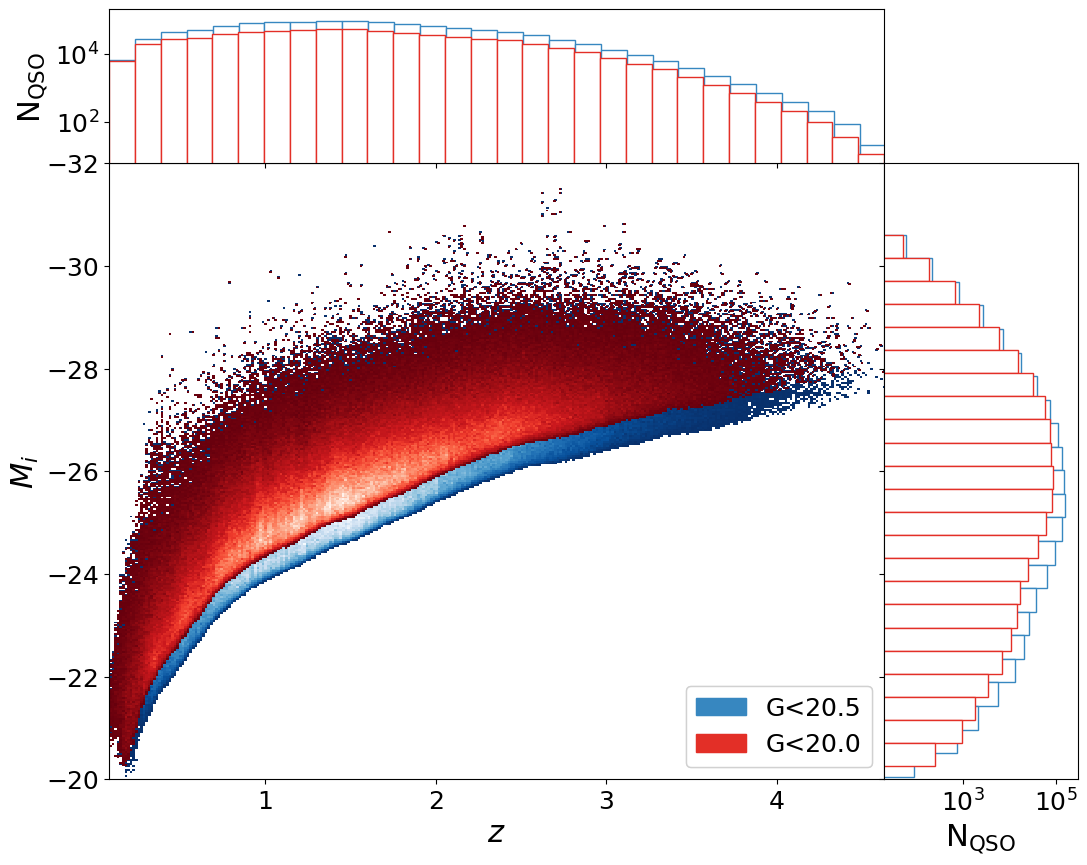

In [18]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
                                       cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()
patch = [mpatches.Patch(color=colors[i], label='G<{}'.format(mag[i])) for i in range(len(colors))] 
first_legend = ax1.legend(handles=patch, loc = 'lower right')
ax1.add_artist(first_legend)

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Model using linear bias $b=\sqrt{\xi_{qq}/\xi_{mm}}$
## First compute $\xi_{qq}$ and ${w_p}_{qq}$

In [19]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [20]:
tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, 0, True, 'z', n_bins = 1,
                                                                                        tab_gcat_type = 'data', fac_rand = 25)

Leaving tab_gcat_catalog unbinned
G20.5: 0.15              1102599 vs 1295502


In [94]:
# cosmology 1
h=0.6844
Omega_m = 0.302

# cosmology 2
Omega_m_quaia = 0.343
h_quaia = 0.674

In [22]:
cf = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, Om0 = Omega_m, h = h)
cf_quaia = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, Om0 = Omega_m_quaia, h = h_quaia)

[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


In [23]:
# Create the bins array
rpmin = 0.15 # 0.5 # 0.1 # start higher
rpmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rpbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [24]:
pimax = 80 # 40 # 5000.0 # 40.0

In [25]:
wp, rpavg = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, Om0 = Omega_m, h = h,
                                                      nthreads = nthreads, rbins = rpbins, nbins = nbins, pimax = pimax)
wp_quaia, rpavg_quaia = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, Om0 = Omega_m_quaia, h = h_quaia,
                                                      nthreads = nthreads, rbins = rpbins, nbins = nbins, pimax = pimax)

In [26]:
color1 = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, 2))[::-1]
color2 = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, 2))[::-1]

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_113945/4274001107.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(rpavg, wp/rpavg, linewidth = 2.5, marker = 'o', label = '$w_{p, \mathrm{Corrfunc}}(r_p)/r_p$', color = color2[0])
/tmp/ipykernel_113945/4274001107.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(rpavg_quaia, wp_quaia/rpavg_quaia, linewidth = 2.5, marker = 'o', label = '$w_{p, \mathrm{Quaia}}(r_p)/r_p$', linestyle = '--',


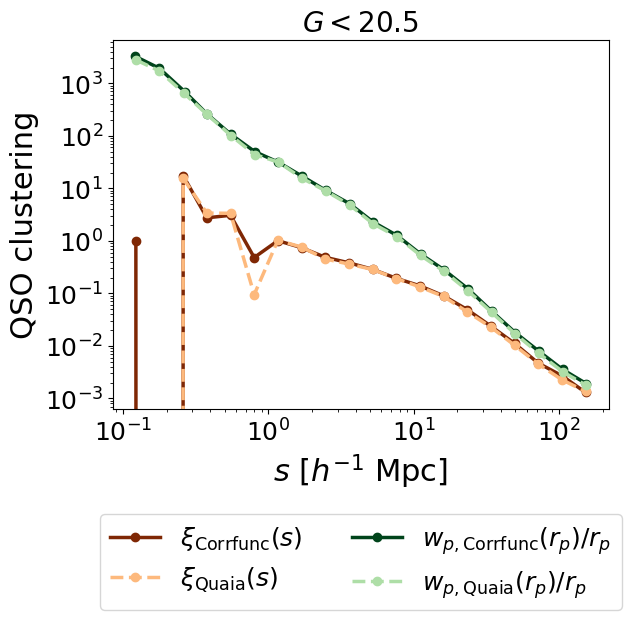

In [96]:
# plot!
# fig = plt.figure(figsize = (20, 8))
# gs = gridspec.GridSpec(1, 2, wspace = 0)

# for i in range(len(G_array)):
    
#     ax1 = fig.add_subplot(gs[i])
    
#     for Lbin, label in zip(L_array, labels):
        
plt.plot(quaia.recenter(rbins), cf, linewidth = 2.5, marker = 'o', label = r'$\xi_\mathrm{Corrfunc}(s)$', color = color1[0])
plt.plot(quaia.recenter(rbins), cf_quaia, linewidth = 2.5, marker = 'o', label = r'$\xi_\mathrm{Quaia}(s)$', linestyle = '--', color = color1[1])

plt.plot(rpavg, wp/rpavg, linewidth = 2.5, marker = 'o', label = '$w_{p, \mathrm{Corrfunc}}(r_p)/r_p$', color = color2[0])
plt.plot(rpavg_quaia, wp_quaia/rpavg_quaia, linewidth = 2.5, marker = 'o', label = '$w_{p, \mathrm{Quaia}}(r_p)/r_p$', linestyle = '--', 
         color = color2[1])

plt.title('$G<{}$'.format(G_hi))
plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
# plt.xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
# plt.ylim(1e-3, 4e1)
plt.ylabel('QSO clustering')
plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.25), loc='upper center')
plt.show()

## Now compute $\xi_{mm}$

In [28]:
H0 = h*100 * u.km/u.s/u.Mpc
rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

### with RSDs

In [101]:
Omega_c = 0.2513
Omega_b = 0.048
Omega_m_planck = Omega_c+Omega_b
cosmo = ccl.Cosmology(Omega_c=Omega_m*Omega_c/Omega_m_planck, Omega_b=Omega_m*Omega_b/Omega_m_planck,
                          h=h, n_s=0.95, sigma8=0.8)
cosmo_quaia = ccl.Cosmology(Omega_c=Omega_m_quaia*Omega_c/Omega_m_planck, Omega_b=Omega_m_quaia*Omega_b/Omega_m_planck,
                          h=h_quaia, n_s=0.95, sigma8=0.766)
# Pk = ccl.nonlin_matter_power(cosmo, 2*np.pi/rbins, a=1/(1+np.mean(tab_datahi_mask_zbin0['redshift_quaia'])))  
a = 1/(1+np.mean(tab_datahi_mask_zbin0['redshift_quaia']))
cf_matter_rsd = ccl.correlations.correlation_3dRsd_avgmu(cosmo, r=rbins_Mpc, a=a, beta = ccl.growth_rate(cosmo, a))
cf_matter_rsd_quaia = ccl.correlations.correlation_3dRsd_avgmu(cosmo_quaia, r=rbins_Mpc, a=a, beta = ccl.growth_rate(cosmo_quaia, a))

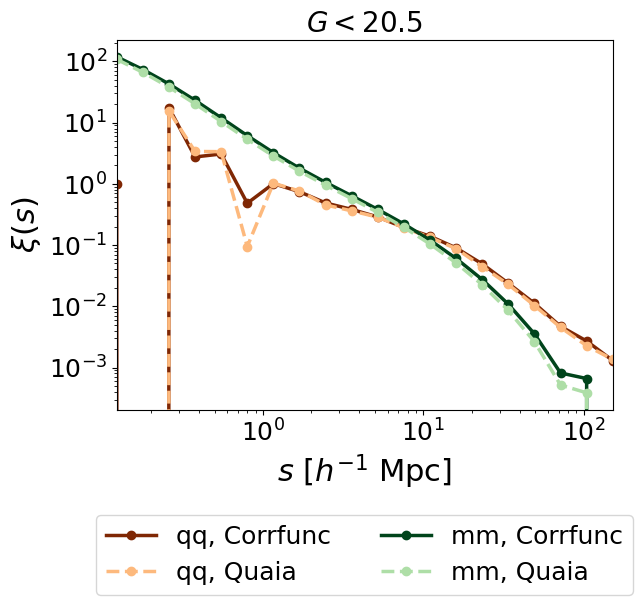

In [102]:
plt.plot(quaia.recenter(rbins), cf, linewidth = 2.5, marker = 'o', label = r'qq, Corrfunc', color = color1[0])
plt.plot(quaia.recenter(rbins), cf_quaia, linewidth = 2.5, marker = 'o', label = r'qq, Quaia', linestyle = '--', 
         color = color1[1])

plt.plot(quaia.recenter(rbins), cf_matter_rsd, linewidth = 2.5, marker = 'o', label = r'mm, Corrfunc', color = color2[0])
plt.plot(quaia.recenter(rbins), cf_matter_rsd_quaia, linewidth = 2.5, marker = 'o', label = r'mm, Quaia', linestyle = '--', 
         color = color2[1])
# plt.plot(rpavg, wp/rpavg, linewidth = 2.5, marker = 'o', label = '$w_p(r_p)/r_p$')

# # plot!
# fig = plt.figure(figsize = (10, 10))
# gs = gridspec.GridSpec(2, 1, height_ratios = [4,1], hspace = 0, wspace = 0)

# ax1 = fig.add_subplot(gs[0])
# ax2 = fig.add_subplot(gs[1])

plt.title('$G<{}$'.format(G_hi))
plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
# plt.ylim(1e-3, 4e1)
plt.ylabel(r'$\xi(s)$')
plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.25), loc='upper center')
plt.show()

In [31]:
color3 = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, 2))[::-1]

/tmp/ipykernel_113945/1715435079.py:1: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(quaia.recenter(rbins), np.sqrt(cf/cf_matter_rsd), linewidth = 2.5, marker = 'o', label = r'Corrfunc', color = color3[0])
/tmp/ipykernel_113945/1715435079.py:2: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(quaia.recenter(rbins), np.sqrt(cf_quaia/cf_matter_rsd_quaia), linewidth = 2.5, marker = 'o', label = r'Quaia',


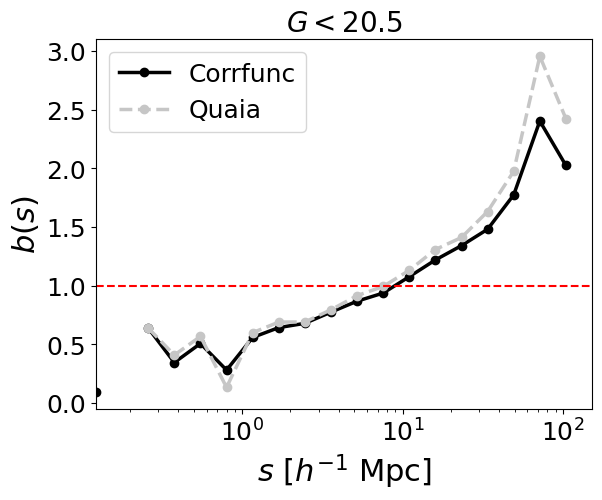

In [103]:
plt.plot(quaia.recenter(rbins), np.sqrt(cf/cf_matter_rsd), linewidth = 2.5, marker = 'o', label = r'Corrfunc', color = color3[0])
plt.plot(quaia.recenter(rbins), np.sqrt(cf_quaia/cf_matter_rsd_quaia), linewidth = 2.5, marker = 'o', label = r'Quaia',
         linestyle = '--', color = color3[1])

plt.title('$G<{}$'.format(G_hi))
plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    plt.xscale('log')
# plt.yscale('log')
plt.ylabel(r'$b(s)$')
           # =\sqrt{\xi_{qq}(s)/\xi_{mm}(s)}$')
plt.axhline(1, linestyle = '--', color = 'red')
plt.xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
plt.legend()
plt.show()

### without RSDs

In [33]:
cf_matter = ccl.correlations.correlation_3d(cosmo, r=rbins_Mpc, a=a)
cf_matter_quaia = ccl.correlations.correlation_3d(cosmo_quaia, r=rbins_Mpc, a=a)

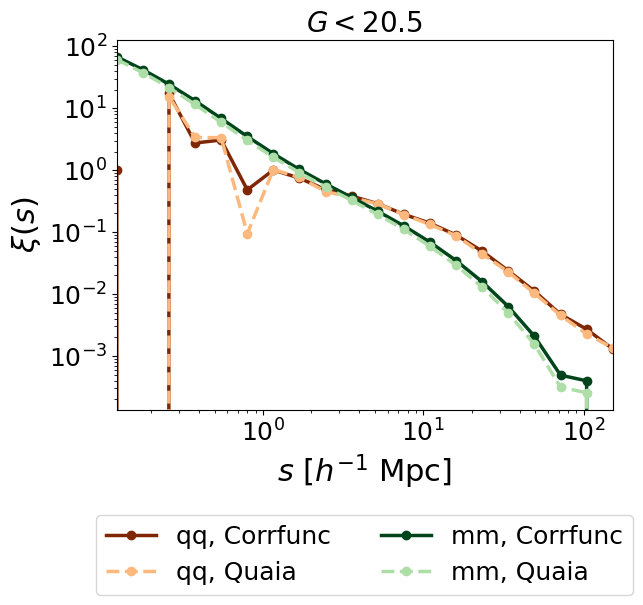

In [97]:
plt.plot(quaia.recenter(rbins), cf, linewidth = 2.5, marker = 'o', label = r'qq, Corrfunc', color = color1[0])
plt.plot(quaia.recenter(rbins), cf_quaia, linewidth = 2.5, marker = 'o', label = r'qq, Quaia', linestyle = '--', 
         color = color1[1])

plt.plot(quaia.recenter(rbins), cf_matter, linewidth = 2.5, marker = 'o', label = r'mm, Corrfunc', color = color2[0])
plt.plot(quaia.recenter(rbins), cf_matter_quaia, linewidth = 2.5, marker = 'o', label = r'mm, Quaia', linestyle = '--', 
         color = color2[1])

# plt.plot(rpavg, wp/rpavg, linewidth = 2.5, marker = 'o', label = '$w_p(r_p)/r_p$')

# # plot!
# fig = plt.figure(figsize = (10, 10))
# gs = gridspec.GridSpec(2, 1, height_ratios = [4,1], hspace = 0, wspace = 0)

# ax1 = fig.add_subplot(gs[0])
# ax2 = fig.add_subplot(gs[1])

plt.title('$G<{}$'.format(G_hi))
plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
# plt.ylim(1e-3, 4e1)
plt.ylabel(r'$\xi(s)$')
plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.25), loc='upper center')
plt.show()

/tmp/ipykernel_113945/1518527324.py:1: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(quaia.recenter(rbins), np.sqrt(cf/cf_matter), linewidth = 2.5, marker = 'o', label = r'Corrfunc', color = color3[0])
/tmp/ipykernel_113945/1518527324.py:2: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(quaia.recenter(rbins), np.sqrt(cf_quaia/cf_matter_quaia), linewidth = 2.5, marker = 'o', label = r'Quaia',


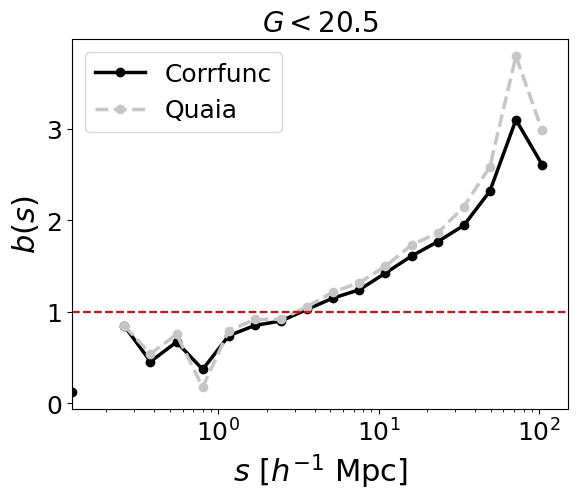

In [98]:
plt.plot(quaia.recenter(rbins), np.sqrt(cf/cf_matter), linewidth = 2.5, marker = 'o', label = r'Corrfunc', color = color3[0])
plt.plot(quaia.recenter(rbins), np.sqrt(cf_quaia/cf_matter_quaia), linewidth = 2.5, marker = 'o', label = r'Quaia',
         linestyle = '--', color = color3[1])

plt.title('$G<{}$'.format(G_hi))
plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    plt.xscale('log')
# plt.yscale('log')
plt.ylabel(r'$b(s)$')
           # =\sqrt{\xi_{qq}(s)/\xi_{mm}(s)}$')
plt.axhline(1, linestyle = '--', color = 'red')
plt.xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
plt.legend()
plt.show()

# Model using linear bias $b=\sqrt{w_{p, qq}/w_{p, mm}}$
## Now compute $w_{p,mm}(r_p)$

In [36]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

### with RSDs

In [37]:
# version 3
s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)**2, quaia.recenter(pibins)**2), axis = 0))

xirppi = ccl.correlations.correlation_3dRsd_avgmu(cosmo, r=np.ravel(s), a=a, beta = ccl.growth_rate(cosmo, a))
xirppi_quaia = ccl.correlations.correlation_3dRsd_avgmu(cosmo_quaia, r=np.ravel(s), a=a, beta = ccl.growth_rate(cosmo_quaia, a))

wp_matter_rsd = 2*np.trapz(np.reshape(xirppi, np.shape(s)), quaia.recenter(pibins), axis = 0)
wp_matter_rsd_quaia = 2*np.trapz(np.reshape(xirppi_quaia, np.shape(s)), quaia.recenter(pibins), axis = 0)

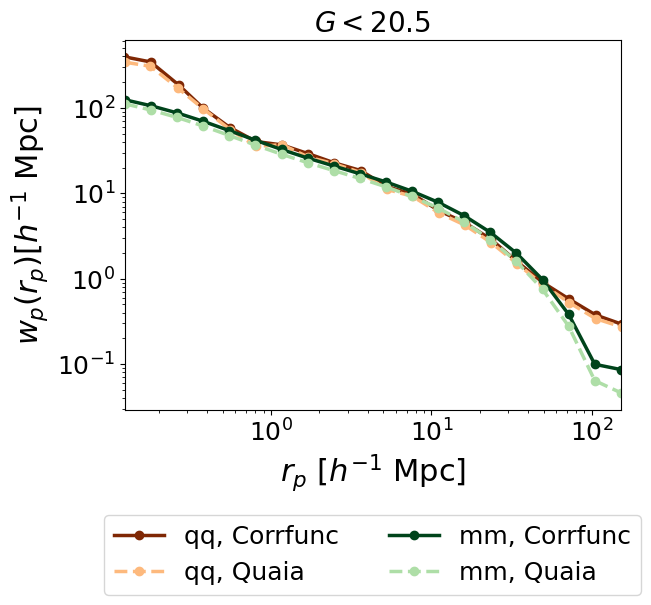

In [104]:
plt.plot(rpavg, wp, linewidth = 2.5, marker = 'o', label = r'qq, Corrfunc', color = color1[0])
plt.plot(rpavg_quaia, wp_quaia, linewidth = 2.5, marker = 'o', label = r'qq, Quaia', linestyle = '--', 
         color = color1[1])

plt.plot(quaia.recenter(rpbins), wp_matter_rsd, linewidth = 2.5, marker = 'o', label = r'mm, Corrfunc', color = color2[0])
plt.plot(quaia.recenter(rpbins), wp_matter_rsd_quaia, linewidth = 2.5, marker = 'o', label = r'mm, Quaia', linestyle = '--', color = color2[1])

plt.title('$G<{}$'.format(G_hi))
plt.xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])
plt.ylabel('$w_p(r_p) [h^{-1}$ Mpc]')
plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.25), loc='upper center')
plt.show()

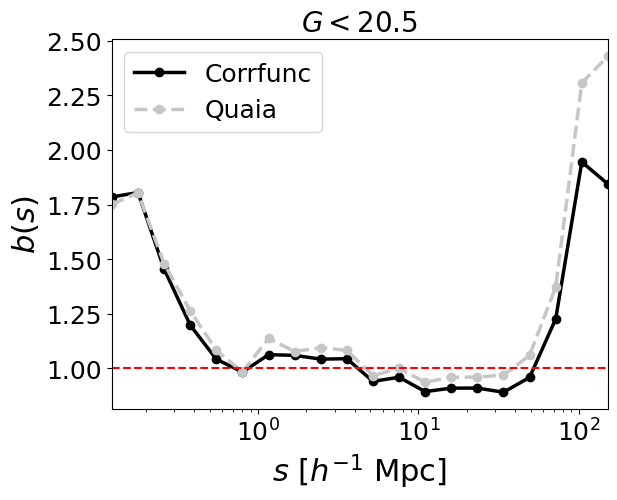

In [118]:
plt.plot(quaia.recenter(rpbins), np.sqrt(wp/wp_matter_rsd), linewidth = 2.5, marker = 'o', label = r'Corrfunc', color = color3[0])
plt.plot(quaia.recenter(rpbins), np.sqrt(wp_quaia/wp_matter_rsd_quaia), linewidth = 2.5, marker = 'o', label = r'Quaia',
         linestyle = '--', color = color3[1])

plt.title('$G<{}$'.format(G_hi))
plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    plt.xscale('log')
plt.ylabel(r'$b(s)$')
plt.axhline(1, linestyle = '--', color = 'red')
plt.xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])
plt.legend()
plt.show()

### without RSDs

In [344]:
# version 1
# wp_array = []
# for pi in pibins:
#     s = np.sqrt(rpbins**2+pi**2)
#     wp_array.append(ccl.correlations.correlation_3d(cosmo, r=s, a=a))
# wp_mm = 2*np.trapz(wp_array, pibins, axis = 0)

In [345]:
# version 2
# s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)**2, quaia.recenter(pibins)**2), axis = 0))
# xirppi = ccl.correlations.correlation_3d(cosmo, r=np.ravel(s.T), a=a)
# npibins = len(xirppi) // nbins
# wp_mm2 = []
# for i in range(nbins):
#     wp_mm2.append(2.0 * dpi * np.sum(xirppi[i * npibins:(i + 1) * npibins]))

In [40]:
# version 3
s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)**2, quaia.recenter(pibins)**2), axis = 0))

xirppi = ccl.correlations.correlation_3d(cosmo, r=np.ravel(s), a=a)
xirppi_quaia = ccl.correlations.correlation_3d(cosmo_quaia, r=np.ravel(s), a=a)

wp_matter = 2*np.trapz(np.reshape(xirppi, np.shape(s)), quaia.recenter(pibins), axis = 0)
wp_matter_quaia = 2*np.trapz(np.reshape(xirppi_quaia, np.shape(s)), quaia.recenter(pibins), axis = 0)

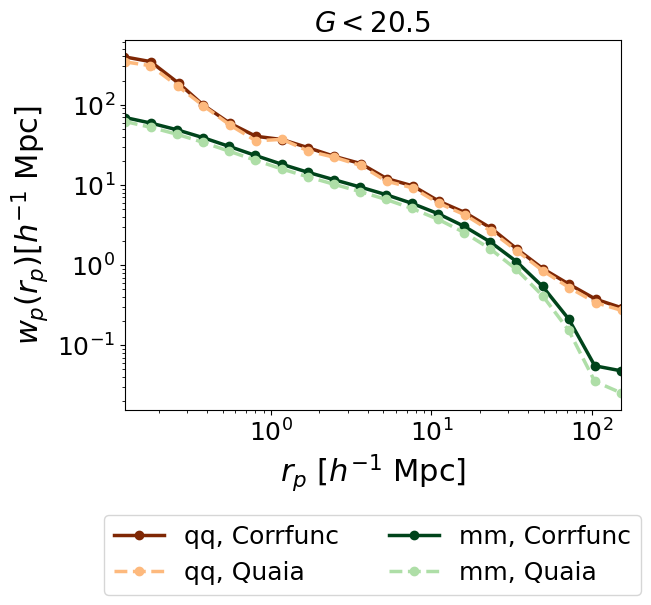

In [99]:
plt.plot(rpavg, wp, linewidth = 2.5, marker = 'o', label = r'qq, Corrfunc', color = color1[0])
plt.plot(rpavg_quaia, wp_quaia, linewidth = 2.5, marker = 'o', label = r'qq, Quaia', linestyle = '--', 
         color = color1[1])

plt.plot(quaia.recenter(rpbins), wp_matter, linewidth = 2.5, marker = 'o', label = r'mm, Corrfunc', color = color2[0])
# plt.plot(quaia.recenter(rpbins), wp_mm2, linewidth = 2.5, marker = 'o', label = r'mm2, corrfunc', color = color2[0], linestyle = '--', alpha = 0.5)
# plt.plot(quaia.recenter(rpbins), wp_mm3, linewidth = 2.5, marker = 'o', label = r'mm3, corrfunc', color = color2[0], linestyle = '-.', alpha = 0.25)
plt.plot(quaia.recenter(rpbins), wp_matter_quaia, linewidth = 2.5, marker = 'o', label = r'mm, Quaia', linestyle = '--', color = color2[1])
# plt.plot(quaia.recenter(rbins), cf_matter_quaia, linewidth = 2.5, marker = 'o', label = r'$\xi_{mm,\mathrm{cosmo2}}(s)$', linestyle = '--', 
#          color = color2[1])

plt.title('$G<{}$'.format(G_hi))
plt.xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])
plt.ylabel('$w_p(r_p) [h^{-1}$ Mpc]')
plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.25), loc='upper center')
plt.show()

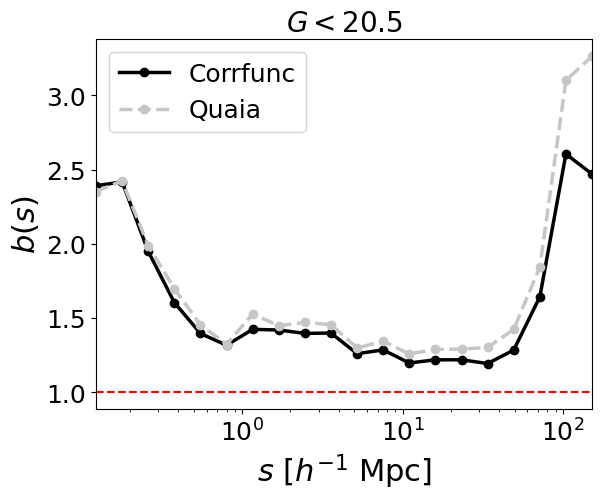

In [117]:
plt.plot(quaia.recenter(rpbins), np.sqrt(wp/wp_matter), linewidth = 2.5, marker = 'o', label = r'Corrfunc', color = color3[0])
plt.plot(quaia.recenter(rpbins), np.sqrt(wp_quaia/wp_matter_quaia), linewidth = 2.5, marker = 'o', label = r'Quaia',
         linestyle = '--', color = color3[1])

plt.title('$G<{}$'.format(G_hi))
plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    plt.xscale('log')
# plt.yscale('log')
plt.ylabel(r'$b(s)$')
           # =\sqrt{w_{p, r_p, qq}(r_p)/w_{p, mm}(r_p)}$')
plt.axhline(1, linestyle = '--', color = 'red')
plt.xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])
plt.legend()
plt.show()

# Measure bias in a narrow $z$ range: 0.9 < $z$ < 2.2 to match Fig. 8 of [this paper](https://arxiv.org/abs/1705.04718)
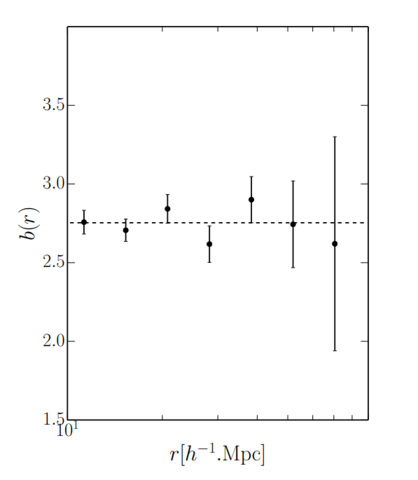
## For $\xi(s)$
### Define a function

In [77]:
def narrow(tab_datahi_mask_zbin0, key_zbin0 = '', z1 = 0.9, z2 = 2.2):
    
    tab_datahi_mask_zbin0_narrow = tab_datahi_mask_zbin0[(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0] > z1) & (tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0] < z2)]
    a = 1/(1+np.mean(tab_datahi_mask_zbin0_narrow['redshift_quaia'+key_zbin0]))
    
    return tab_datahi_mask_zbin0_narrow, a

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_113945/3665220722.py:29: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_narrow[i]/cf_matter_narrow[i]), linewidth = 2.5, marker = 'o', label = label_array[i], color = color3[i], linestyle = linestyles[i])


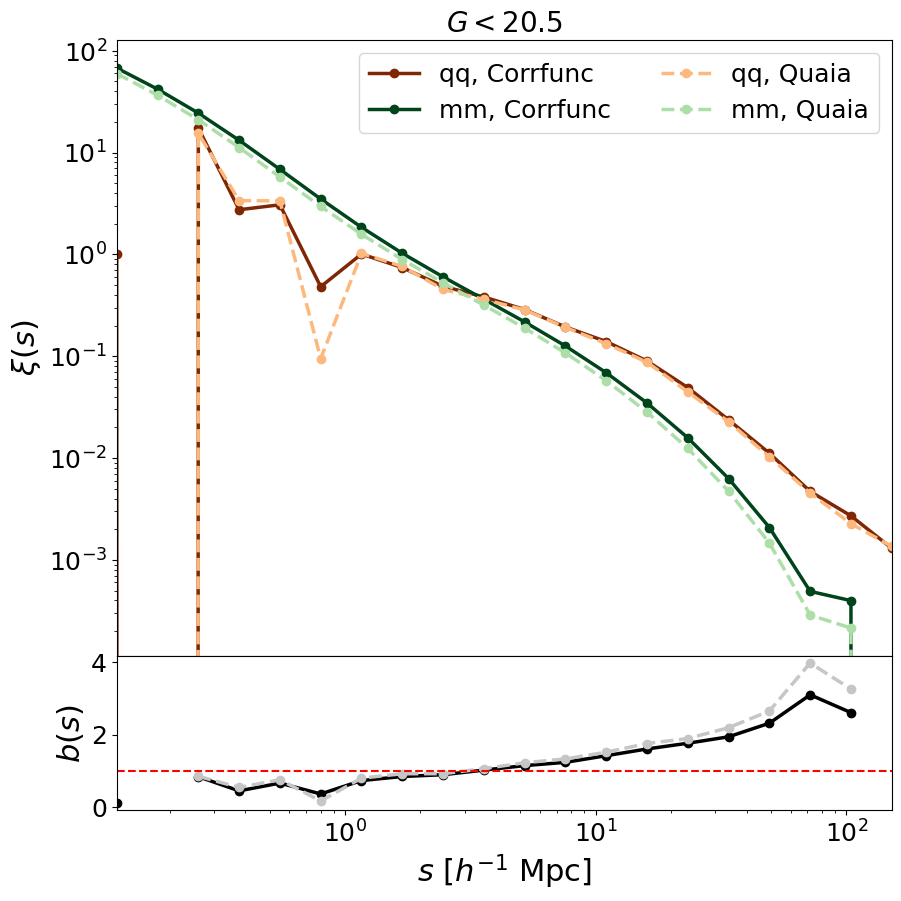

In [110]:
# test!
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmo_array = [cosmo, cosmo_quaia]
linestyles = ['-', '--']

fig = plt.figure(figsize = (10, 10))
gs = gridspec.GridSpec(2, 1, hspace = 0, height_ratios = [4,1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

cf_narrow, cf_matter_narrow = [], []
for i in range(len(Omega_m_array)):
    
    tab_datahi_mask_zbin0_narrow, a = narrow(tab_datahi_mask_zbin0, z1 = 0, z2 = 5)
    cf_narrow.append(quaia.xi_s(tab_datahi_mask_zbin0_narrow, narrow(tab_randhi_mask_zbin0, key_zbin0 = '_'+key_zbin0, z1 = 0, z2 = 5)[0], key_zbin0, nthreads = nthreads, 
               rbins = rbins, Om0 = Omega_m_array[i], h = h_array[i]))

    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

    cf_matter_narrow.append(ccl.correlations.correlation_3d(cosmo_array[i], r=rbins_Mpc, a=a))
    
    ax1.plot(quaia.recenter(rbins), cf_narrow[i], linewidth = 2.5, marker = 'o', label = r'qq, '+ label_array[i], color = color1[i], linestyle = linestyles[i])

    ax1.plot(quaia.recenter(rbins), cf_matter_narrow[i], linewidth = 2.5, marker = 'o', label = r'mm, '+label_array[i], color = color2[i], linestyle = linestyles[i])
    
    ax2.plot(quaia.recenter(rbins), np.sqrt(cf_narrow[i]/cf_matter_narrow[i]), linewidth = 2.5, marker = 'o', label = label_array[i], color = color3[i], linestyle = linestyles[i])

ax1.set_title('$G<{}$'.format(G_hi))
if scale == 'log':
    ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_ylabel(r'$\xi(s)$')
ax1.legend(ncol = 2)
ax1.set_xticklabels([])

ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    ax2.set_xscale('log')
ax2.set_ylabel(r'$b(s)$')
ax2.axhline(1, linestyle = '--', color = 'red')
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])

plt.show()

In [111]:
# def bias(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, cosmo, z1 = 0, z2 = 5, nthreads = nthreads, rbins = rbins, Om0 = Omega_m, h = h):
# z1 = 0.9
# z2 = 2.2
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmo_array = [cosmo, cosmo_quaia]
linestyles = ['-', '--']

cf_narrow, cf_matter_narrow = [], []
# for Omega_m, h, cosmo, label in zip([Omega_m, Omega_m_quaia], [h, h_quaia], [cosmo, cosmo_quaia], ['corrfunc', 'quaia']):
for i in range(len(Omega_m_array)):
    
    tab_datahi_mask_zbin0_narrow, a = narrow(tab_datahi_mask_zbin0)
    cf_narrow.append(quaia.xi_s(tab_datahi_mask_zbin0_narrow, narrow(tab_randhi_mask_zbin0, key_zbin0 = '_'+key_zbin0)[0], key_zbin0, nthreads = nthreads, 
               rbins = rbins, Om0 = Omega_m_array[i], h = h_array[i]))

    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    # a = 1/(1+np.mean(narrow(tab_datahi_mask_zbin0['redshift_quaia'])))

    cf_matter_narrow.append(ccl.correlations.correlation_3d(cosmo_array[i], r=rbins_Mpc, a=a))

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


/tmp/ipykernel_113945/1594117459.py:19: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(quaia.recenter(rbins), np.sqrt(cf_narrow[i]/cf_matter_narrow[i]), linewidth = 2.5, marker = 'o', label = label_array[i], color = color3[i], linestyle = linestyles[i])


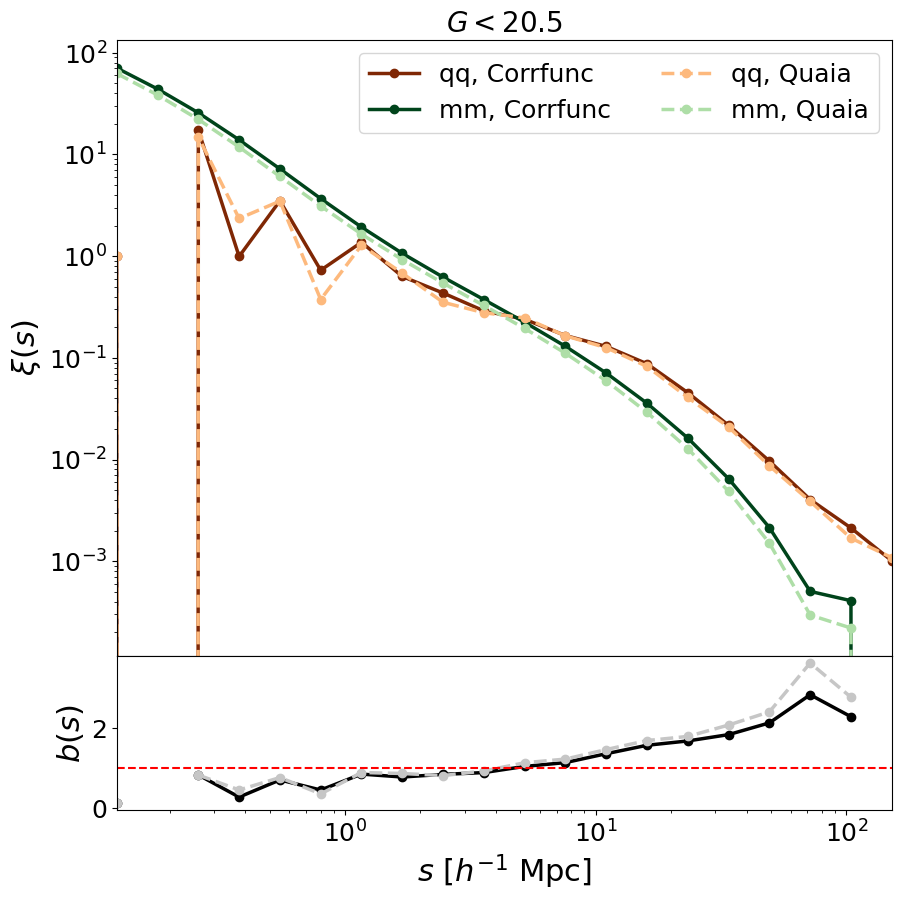

In [112]:
fig = plt.figure(figsize = (10, 10))
gs = gridspec.GridSpec(2, 1, hspace = 0, height_ratios = [4,1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

label_array = ['Corrfunc', 'Quaia']
# for Omega_m, h, cosmo, label in zip([Omega_m, Omega_m_quaia], [h, h_quaia], [cosmo, cosmo_quaia], ['corrfunc', 'quaia']):
for i in range(len(Omega_m_array)):
    
    ax1.plot(quaia.recenter(rbins), cf_narrow[i], linewidth = 2.5, marker = 'o', label = r'qq, '+ label_array[i], color = color1[i], linestyle = linestyles[i])
    # plt.plot(quaia.recenter(rbins), cf_quaia, linewidth = 2.5, marker = 'o', label = r'qq, quaia', linestyle = '--', 
    #          color = color1[1])

    ax1.plot(quaia.recenter(rbins), cf_matter_narrow[i], linewidth = 2.5, marker = 'o', label = r'mm, '+label_array[i], color = color2[i], linestyle = linestyles[i])
    # plt.plot(quaia.recenter(rbins), cf_matter_quaia, linewidth = 2.5, marker = 'o', label = r'mm, quaia', linestyle = '--', 
    #          color = color2[1])
    
    ax2.plot(quaia.recenter(rbins), np.sqrt(cf_narrow[i]/cf_matter_narrow[i]), linewidth = 2.5, marker = 'o', label = label_array[i], color = color3[i], linestyle = linestyles[i])
    # plt.plot(quaia.recenter(rbins), np.sqrt(cf_quaia/cf_matter_quaia), linewidth = 2.5, marker = 'o', label = r'quaia',
    #          linestyle = '--', color = color3[1])

ax1.set_title('$G<{}$'.format(G_hi))
              # , {} < z < {}$'.format(G_hi, 0.9, 2.2))
# plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_ylabel(r'$\xi(s)$')
ax1.legend(ncol = 2)
           # , bbox_to_anchor = (0.5, -0.25), loc='upper center')
ax1.set_xticklabels([])

# plt.title('$G<{}$'.format(G_hi))
ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    ax2.set_xscale('log')
ax2.set_ylabel(r'$b(s)$')
ax2.axhline(1, linestyle = '--', color = 'red')
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
# plt.legend()

plt.show()

## For $w_p(r_p)$

In [116]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmo_array = [cosmo, cosmo_quaia]
linestyles = ['-', '--']

wp_narrow, wp_matter_narrow = [], []
rpavg_narrow = []
for i in range(len(Omega_m_array)):
    
    tab_datahi_mask_zbin0_narrow, a = narrow(tab_datahi_mask_zbin0)
    wp_narrow_i, rpavg_narrow_i = quaia.wp_rp(tab_datahi_mask_zbin0_narrow, narrow(tab_randhi_mask_zbin0, key_zbin0 = '_'+key_zbin0)[0], key_zbin0, Om0 = Omega_m_array[i], h = h_array[i],
                                                      nthreads = nthreads, rbins = rpbins, nbins = nbins, pimax = pimax)
    wp_narrow.append(wp_narrow_i)
    rpavg_narrow.append(rpavg_narrow_i)

    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

    cf_matter_narrow.append(ccl.correlations.correlation_3d(cosmo_array[i], r=rbins_Mpc, a=a))# def bias(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, cosmo, z1 = 0, z2 = 5, nthreads = nthreads, rbins = rbins, Om0 = Omega_m, h = h):
    
    # version 3
    xirppi_narrow = ccl.correlations.correlation_3d(cosmo_array[i], r=np.ravel(s), a=a)
    wp_matter_narrow.append(2*np.trapz(np.reshape(xirppi_narrow, np.shape(s)), quaia.recenter(pibins), axis = 0))

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


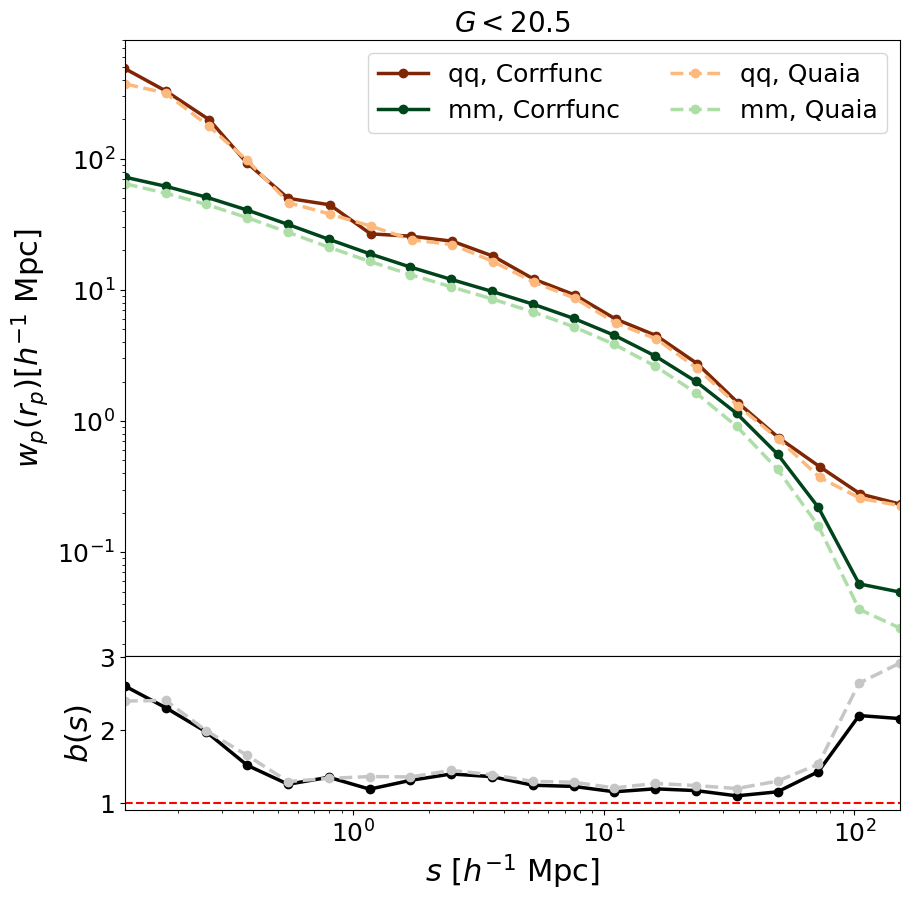

In [122]:
fig = plt.figure(figsize = (10, 10))
gs = gridspec.GridSpec(2, 1, hspace = 0, height_ratios = [4,1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

label_array = ['Corrfunc', 'Quaia']
for i in range(len(Omega_m_array)):
    
    ax1.plot(rpavg_narrow[i], wp_narrow[i], linewidth = 2.5, marker = 'o', label = r'qq, '+ label_array[i], color = color1[i], linestyle = linestyles[i])
    ax1.plot(quaia.recenter(rpbins), wp_matter_narrow[i], linewidth = 2.5, marker = 'o', label = r'mm, '+label_array[i], color = color2[i], linestyle = linestyles[i])
    
    ax2.plot(quaia.recenter(rpbins), np.sqrt(wp_narrow[i]/wp_matter_narrow[i]), linewidth = 2.5, marker = 'o', label = label_array[i], color = color3[i], linestyle = linestyles[i]) # not sure which x axis to plot against lol

ax1.set_title('$G<{}$'.format(G_hi))
if scale == 'log':
    ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])
ax1.set_ylabel(r'$w_p(r_p) [h^{-1}$ Mpc]')
ax1.legend(ncol = 2)
ax1.set_xticklabels([])

ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    ax2.set_xscale('log')
ax2.set_ylabel(r'$b(s)$')
ax2.axhline(1, linestyle = '--', color = 'red')
ax2.set_xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])

plt.show()